# Shoreline Detection Technique Performance Evaluation

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("shoreline-detection-scores.xlsx")
df

,#,Season,Technique,Year,Northwest Beach,Southwest Beach,Southeast Beach
0,1,Early,K-means,2018,4,4,2
1,2,Early,K-means,2019,4,4,4
2,3,Early,K-means,2020,4,4,4
3,4,Early,K-means,2021,4,4,4
4,5,Early,K-means,2022,4,4,2
...,...,...,...,...,...,...,...
71,21,Late,SAM,2020,1,2,3
72,22,Late,SAM,2021,1,2,1
73,23,Late,SAM,2022,2,2,1
74,24,Late,SAM,2023,2,2,1


In [47]:
# Clean SW and SE columns
df['Southwest Beach'] = df['Southwest Beach'].replace('-', np.nan).astype(float)
df['Southeast Beach'] = df['Southeast Beach'].replace('-', np.nan).astype(float)
df

C:\Users\Move\AppData\Local\Temp\ipykernel_34104\1533342522.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Southwest Beach'] = df['Southwest Beach'].replace('-', np.nan).astype(float)
C:\Users\Move\AppData\Local\Temp\ipykernel_34104\1533342522.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Southeast Beach'] = df['Southeast Beach'].replace('-', np.nan).astype(float)


,#,Season,Technique,Year,Northwest Beach,Southwest Beach,Southeast Beach
0,1,Early,K-means,2018,4,4.0,2.0
1,2,Early,K-means,2019,4,4.0,4.0
2,3,Early,K-means,2020,4,4.0,4.0
3,4,Early,K-means,2021,4,4.0,4.0
4,5,Early,K-means,2022,4,4.0,2.0
...,...,...,...,...,...,...,...
71,21,Late,SAM,2020,1,2.0,3.0
72,22,Late,SAM,2021,1,2.0,1.0
73,23,Late,SAM,2022,2,2.0,1.0
74,24,Late,SAM,2023,2,2.0,1.0


In [48]:
# Optional: rename long columns for convenience
regions = ['Northwest Beach', 'Southwest Beach', 'Southeast Beach']

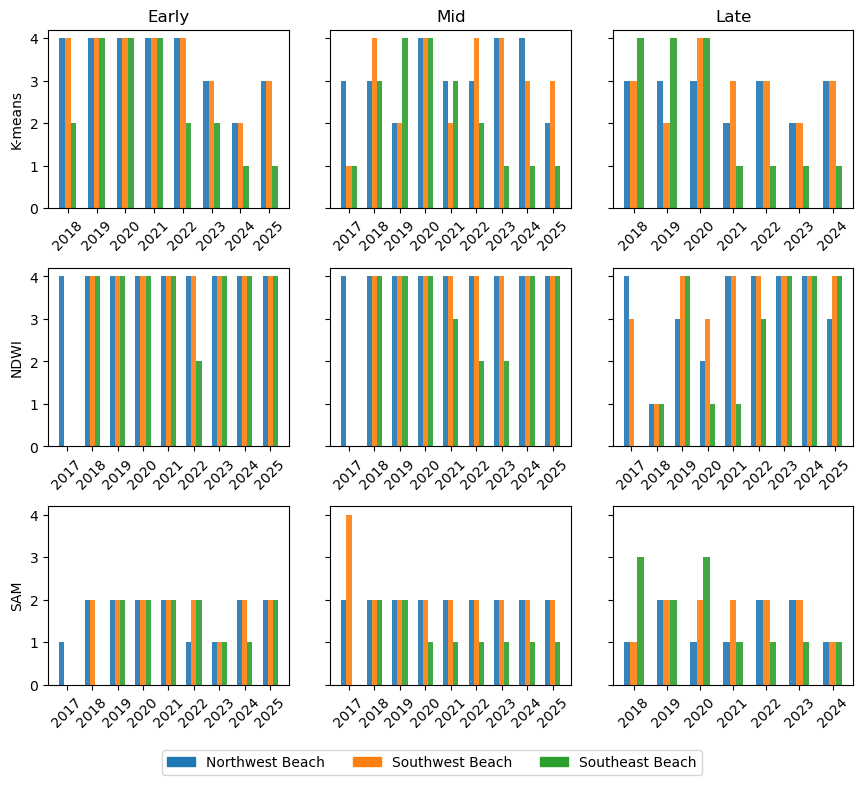

In [86]:
from matplotlib.colors import to_rgb, to_hex

# 3x3 grid: rows = techniques, cols = seasons
seasons = ['Early', 'Mid', 'Late']  # adjust order if needed
techniques = df['Technique'].unique()
bar_width = 0.2
plot_colors = ['C0', 'C1', 'C2']

n_rows = len(techniques)
n_cols = len(seasons)
# do not share x-axis (each subplot may have different years/data availability)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.5*n_rows), sharex=False, sharey=True)
axs = np.atleast_2d(axs)

for r, t in enumerate(techniques):
    for c, s in enumerate(seasons):
        ax = axs[r, c]
        temp = df[(df['Technique'] == t) & (df['Season'] == s)].groupby('Year')[regions].mean().reset_index()
        if temp.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_xlabel('Year')
            continue

        x = np.arange(len(temp['Year']))
        for i, col in enumerate(regions):
            ax.bar(x + i*bar_width, temp[col], width=bar_width, label=col if (r == 0 and c == 0) else None, color=plot_colors[i], alpha=0.90)
        if r == 0:
            ax.set_title(s)
        if c == 0:
            ax.set_ylabel(t)

        # set x ticks/labels per subplot (not shared)
        ax.set_xticks(x + bar_width*(len(regions)-1)/2)
        ax.set_xticklabels(temp['Year'].astype(str), rotation=45)
        ax.grid(True, axis='y', linestyle='--', alpha=0.0)

# place a single legend centered at the bottom of the entire figure
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=plot_colors[i], label=regions[i]) for i in range(len(regions))]
fig.legend(handles=handles, loc='lower center', ncol=len(regions), bbox_to_anchor=(0.5, -0.05), frameon=True)
#plt.subplots_adjust(bottom=0.18)

# hide any other legends
for (rr, cc), a in np.ndenumerate(axs):
    if not (rr == (n_rows - 1) and cc == (n_cols - 1)):
        lg = a.get_legend()
        if lg:
            lg.remove()

plt.subplots_adjust(wspace=5, hspace=8)  # Adjust spacing between plots
plt.tight_layout()
plt.show()
